### 0️⃣ Imports & Style

In [1]:
# %load_ext is safe to repeatedly run in a Jupyter notebook; it will just ignore duplicates.
#%reload_ext autoreload
#%autoreload 2
%matplotlib inline

In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
mpl.rcParams["font.family"] = "DejaVu Sans"   # works on all OSes

# Figures
import seaborn as sns
sns.set_theme(style="darkgrid",      # seaborn grid style
              context="notebook",    # good default size
              font_scale=0.8,
              )
#plt.rcParams.update({
#    "figure.figsize": (8, 5),
#    "font.size": 12,
#    "axes.labelsize": 13,
#    "axes.titlesize": 14,
#    "legend.fontsize": 11,
#    "lines.linewidth": 2,
#})

# Repo imports (assumes repo root is on PYTHONPATH)
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
from model import InverseSchrodingerModel
from utils import make_grid, set_global_seed, l2_inner_product
from physics import tise_loss, potential_smoothness_loss, energy_ordering_loss
from inverse import data_mismatch_loss
from pod import pod_decomposition, cross_overlap_matrix
from train import train_step
from visualizations import *

set_global_seed(27, deterministic=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)
print(f"Using device: {device}")
print(f"Using dtype : {torch.get_default_dtype()}")

Using device: cpu
Using dtype : torch.float64


## Part 1 - Training the Model

### 1️⃣ Synthetic problem definition

### Create spatial grid

In [3]:
# Spatial grid
n_points = 256        # Number of collocation points
x = make_grid(-5.0, 5.0, n_points)       # (n_points, 1) -> n_points collocation points
dx = float(x[1] - x[0])                  # grid spacing (scalar)
print(dx)

0.039215686274509665


### Make sure the grid is approximately uniform on the order of 1e-6 maximum

In [4]:
# Analytical spacing (exact, avoids cumulative rounding)
dx_analytic = ((x[-1] - x[0]) / (x.shape[0] - 1)).item()

# Difference between consecutive points (first interval)
dx_first = (x[1] - x[0]).item()

# Max deviation among all intervals
max_dev = torch.max(torch.abs(torch.diff(x.squeeze()) - dx_first)).item()

print(f"Analytic Delta    : {dx_analytic:.12f}")
print(f"First interval    : {dx_first:.12f}")
print(f"Max deviation     : {max_dev:.2e}")

Analytic Delta    : 0.039215686275
First interval    : 0.039215686275
Max deviation     : 8.88e-16


### Create a 1-D harmonic oscillator test case for the inverse Schrödinger model to try and recover.

In [5]:
# Choose a known analytic potential (e.g., harmonic oscillator)
set_global_seed(27, deterministic=True)  # Ensure data generation is deterministic
V_true = 0.5 * x.squeeze()**2       # shape (N,)

# Analytic eigenfunctions (Hermite-Gaussians) for the chosen analytic potential (harmonic oscillator)
def hermite_gauss(n: int, x_vals: torch.Tensor) -> torch.Tensor:
    """Return the nth normalized harmonic oscillator eigenfunction."""
    from math import factorial, sqrt, pi
    import scipy.special as sp
    norm = 1.0 / sqrt(2.0**n * factorial(n)) * (pi**-0.25)
    # sp.hermite returns a callable polynomial; evaluate on x_vals
    return norm * sp.hermite(n)(x_vals) * torch.exp(-0.5 * x_vals**2)

n_states = 3     # number of eigenstates to evaluate/learn
psi_true = [hermite_gauss(n, x.squeeze()) for n in range(n_states)]
E_true = torch.arange(n_states, dtype=torch.float64) + 0.5  # exact energies (hbar = omega = 1)
print(E_true)   # quick sanity check

# Synthetic observed data with some noise so the model has something to fit
set_global_seed(27, deterministic=True) # Reset seed before noise generation
rho_obs = [psi**2 + 0.02 * torch.randn_like(psi) for psi in psi_true]
E_obs = E_true + 0.05 * torch.randn_like(E_true)

tensor([0.5000, 1.5000, 2.5000])


### 2️⃣ Training loop
Train the inverse Schrödinger model on synthetic observed data (defined above).

In [6]:
#===========================================================================
# 🎛️ CONFIGURATION PARAMETERS
#===========================================================================
# Training hyperparameters
lr              = 5e-3      # Learning rate
epochs          = 6_000     # Number of training epochs
log_every       = 800       # Print loss every N epochs

# Loss weights (static throughout training)
lamda_data      = 1.5
lambda_physics  = 0.5
lambda_smooth   = 0.05
lambda_ordered  = 1.0

# Build the network
set_global_seed(27, deterministic=True)  # Ensure model initialization is deterministic
model = InverseSchrodingerModel(
    n_states=n_states,
    hidden_dims=[64, 64],
    device=device,
    dx=dx
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

lambdas = {
    "data": lamda_data,
    "physics": lambda_physics,
    "smooth": lambda_smooth,
    "ordered": lambda_ordered,
}

# ----------------------------------------------------------------------
# Training loop (with component logging)
# ----------------------------------------------------------------------

loss_history = []
physics_history = []    # TISE  residual
data_history = []       # data-fit
smooth_history = []     # potential smoothness
ortho_history = []      # normalized wavefunction penalty
ordered_history = []    # ordered energy penalty

for epoch in range(1, epochs + 1):
    # Run a single optimization step and retrieve the three components
    optimizer.zero_grad()

    total_loss, loss_physics, loss_data, loss_smooth, loss_ordered = train_step(model, x, dx, rho_obs, E_obs, lambdas)

    total_loss.backward()
    optimizer.step()

    # ------------------- Store scalars ---------------------------
    loss_history.append(total_loss.item())
    physics_history.append(loss_physics.item())
    data_history.append(loss_data.item())
    smooth_history.append(loss_smooth.item())
    ordered_history.append(loss_ordered.item())

    # ----- logging -----------------------------------------------
    if epoch % log_every == 0 or epoch == 1:
        print(f" epoch {epoch:4d} | total={total_loss.item():.2e} "
              f" | phys={loss_physics.item():.2e} "
              f" | data={loss_data.item():.2e}"
              f" | smooth={loss_smooth.item():.2e}"
              f" | ordered={loss_ordered.item():.2e}"
              )

# ----------------------------------------------------------------------
# Post-training sanity check
# ----------------------------------------------------------------------
initial_loss = loss_history[0]
final_loss = loss_history[-1]
print("\n ✔️ Training complete!")
print(f"Initial loss: {initial_loss:.6e}")
print(f"Final loss: {final_loss:.6e}")

 epoch    1 | total=1.69e+00  | phys=2.29e-01  | data=3.48e-01 | smooth=2.12e+01 | ordered=0.00e+00
 epoch  800 | total=3.41e+00  | phys=9.10e-01  | data=8.86e-03 | smooth=5.88e+01 | ordered=0.00e+00
 epoch 1600 | total=7.72e-01  | phys=1.44e+00  | data=6.41e-03 | smooth=8.46e-01 | ordered=0.00e+00
 epoch 2400 | total=2.32e+01  | phys=1.64e+01  | data=2.65e-02 | smooth=3.00e+02 | ordered=0.00e+00
 epoch 3200 | total=2.32e+01  | phys=1.64e+01  | data=3.00e-02 | smooth=2.99e+02 | ordered=0.00e+00
 epoch 4000 | total=2.31e+01  | phys=1.64e+01  | data=3.13e-02 | smooth=2.97e+02 | ordered=0.00e+00
 epoch 4800 | total=2.30e+01  | phys=1.63e+01  | data=3.10e-02 | smooth=2.95e+02 | ordered=0.00e+00
 epoch 5600 | total=2.28e+01  | phys=1.63e+01  | data=3.20e-02 | smooth=2.92e+02 | ordered=0.00e+00

 ✔️ Training complete!
Initial loss: 1.694258e+00
Final loss: 2.267372e+01


#### Build a DataFrame for the loss history

In [7]:
epoch_numbers = list(range(1, len(loss_history) + 1))

df = pd.DataFrame(
    {
        "epoch": epoch_numbers,
        "total": loss_history,
        "physics": physics_history,
        "data": data_history,
        "smooth": smooth_history,
        "ordered": ordered_history,
    }
)

## Part 2 - Generate Figures to Analyze

### 1️⃣ Plot the loss curves

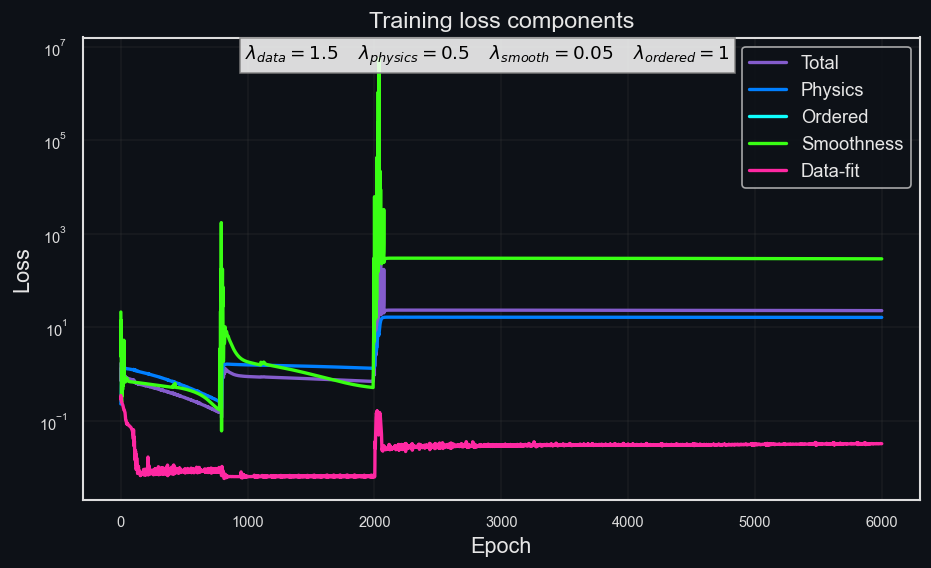

In [8]:
loss_path = pathlib.Path("../artifacts/demo_visuals/training_curves.png")
fig = plot_loss_history(
    epochs=df["epoch"],
    total=df["total"],
    physics=df["physics"],
    data=df["data"],
    smooth=df["smooth"],
    ordered=df["ordered"],
    lambdas=lambdas,
    out_path=loss_path,
)

## 2️⃣ Figure 2: Learned potential vs. Ground truth potential

### 📈 Plot
- $V_\theta(x)$ vs. $x$
- Ground truth $V(x)$ vs. $x$

### 🏡 Messages
- Smoothness prior effect
- Identifiability limits
- Bias vs. variance tradeoff

### ✖️ Failure modes
- Flattening
- Over-smoothing
- Boundary artifacts

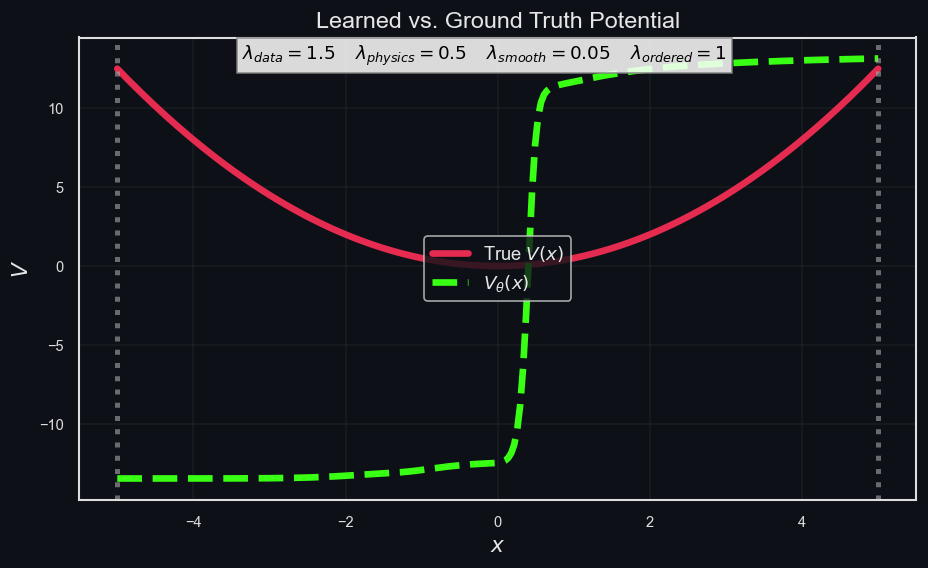

In [9]:
# Extract tensors -> ensure they are on CPU for Matplotlib
V_true_tensor = V_true.squeeze().cpu()
V_learned_tensor = model.V_theta(x).squeeze().detach().cpu()

potential_path = pathlib.Path("../artifacts/demo_visuals/learned_potential.png")
fig = plot_potential(
    x=x,
    V_true=V_true_tensor,
    V_learned=V_learned_tensor,
    lambdas=lambdas,
    out_path=potential_path,
)

### 3️⃣ Figure 3: Learned wave function $\hat{\psi}_n^\theta(x)$
#### 📈 Plot
- Learned $\hat{\psi}_0^\theta$, $\hat{\psi}_1^\theta$ and $\hat{\psi}_2^\theta$ vs. Ground Truth $\psi_0$, $\psi_1$ and $\psi_2$  (3 subplots)

#### 🏘️ Messages
- Phase ambiguity
- Shape consistency
- Node Structure

> ✨ Do _not_ claim correctness; just structure.

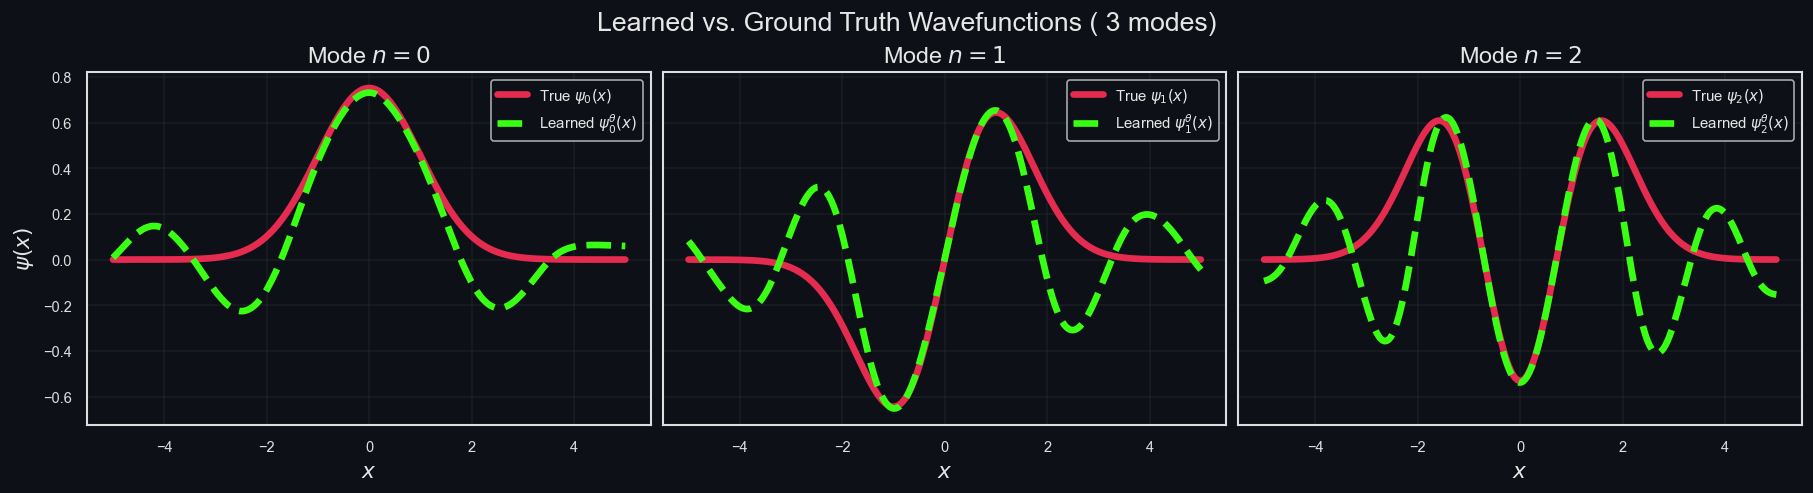

In [10]:
def _as_float(
    tensor: torch.Tensor,
    target_dtype: torch.dtype = torch.float64,
) -> torch.Tensor:
    """Return a contiguous 1-D tensor with the desired dtype."""
    return tensor.squeeze().to(dtype=target_dtype)

# Aligned signs
aligned_psi = []
for true_wf, learned_wf in zip(psi_true, model.psi_theta(x, dx)):
    true_fp = _as_float(true_wf)        # defaults to float64
    learned_fp = _as_float(learned_wf)  # ensures learned_fp is also float64
    overlap = l2_inner_product(true_fp, learned_fp, dx)
    aligned_psi.append(-learned_wf if overlap < 0 else learned_wf)

psi_learned_detached = [
    wf.detach() for wf in aligned_psi
]

psi_true_detached = [
    wf.detach() for wf in psi_true
]

wf_path = pathlib.Path("../artifacts/demo_visuals/learned_wavefunctions.png")
fig = plot_wavefunctions(
    x=x,
    psi_true=psi_true_detached,
    psi_learned=psi_learned_detached,
    out_path=wf_path,
)

### Quick Diagnostics

In [11]:
# --------------------------------------------------------------
# 1️⃣ Verify data flow & basic statistics (you already did this)
# --------------------------------------------------------------
print("x shape:", x.shape)                     # (n_points, 1)
print("V_true min / max:", V_true.min().item(), V_true.max().item())
print("psi_true means :", [p.mean().item() for p in psi_true])
print("psi_learned means :", [p.mean().item() for p in psi_learned_detached])

# --------------------------------------------------------------
# 2️⃣ Re‑compute the loss components for the *current* forward pass
# --------------------------------------------------------------
model.train()                     # put the model in training mode (drops dropout, etc.)

V_pred      = model.V_theta(x)                # (N, 1)
psi_pred    = model.psi_theta(x, dx)          # list of (N, 1) tensors
E_pred      = model.E_theta()                 # (n_states,)

# ------------------------------------------------------------------
# 3️⃣ Compute each loss term (same formulas you use in train_step)
# ------------------------------------------------------------------
# Physics (TISE) loss
L_physics = tise_loss(psi_pred, V_pred, E_pred, dx)

# Smoothness regularizer on the potential
L_smooth = potential_smoothness_loss(V_pred, dx)

# Data‑fit loss (density + energy)
L_data = data_mismatch_loss(psi_pred, E_pred, rho_obs, E_obs, dx)

# Energy ordering loss
L_ordered = energy_ordering_loss(E_pred)

# Weighted total loss – use the same λ’s you defined earlier
total_loss = (
    lambdas["data"]    * L_data
    + lambdas["physics"] * L_physics
    + lambdas["smooth"]  * L_smooth
    + lambdas["ordered"] * L_ordered
)

print("\n--- Loss breakdown (current forward pass) ---")
print(f"Physics loss   : {L_physics.item():.6e}")
print(f"Smoothness loss: {L_smooth.item():.6e}")
print(f"Data loss      : {L_data.item():.6e}")
print(f"Energy ordering loss: {L_ordered.item():.6e}")
print(f"TOTAL loss     : {total_loss.item():.6e}")

# --------------------------------------------------------------
# 4️⃣ Back‑propagate to get gradients
# --------------------------------------------------------------
model.zero_grad()                # clears any stale grads
total_loss.backward()           # now gradients are populated

# --------------------------------------------------------------
# 5️⃣ Report mean absolute gradient magnitude per parameter
# --------------------------------------------------------------
print("\n--- Gradient magnitudes (mean absolute) ---")
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_mean = param.grad.abs().mean().item()
        print(f"{name:30s}  {grad_mean:.3e}")
    else:
        print(f"{name:30s}  No grad")

x shape: torch.Size([256, 1])
V_true min / max: 0.0001922337562475957 12.5
psi_true means : [0.18754368998200965, -6.515933295651714e-19, 0.13260983178440694]
psi_learned means : [0.1328616612155849, 0.002136118138414485, 0.03556974422182732]

--- Loss breakdown (current forward pass) ---
Physics loss   : 1.623971e+01
Smoothness loss: 2.900942e+02
Data loss      : 3.254145e-02
Energy ordering loss: 0.000000e+00
TOTAL loss     : 2.267338e+01

--- Gradient magnitudes (mean absolute) ---
energies                        2.898e-04
potential_net.net.0.weight      2.569e+00
potential_net.net.0.bias        4.312e+00
potential_net.net.2.weight      2.364e-01
potential_net.net.2.bias        6.329e-01
potential_net.net.4.weight      2.740e+00
potential_net.net.4.bias        3.947e+00
psi_nets.0.base_net.net.0.weight  7.424e-04
psi_nets.0.base_net.net.0.bias  3.568e-04
psi_nets.0.base_net.net.2.weight  1.262e-04
psi_nets.0.base_net.net.2.bias  1.635e-04
psi_nets.0.base_net.net.4.weight  1.312e-02


### 4️⃣ Figure 4: Energy spectrum comparison

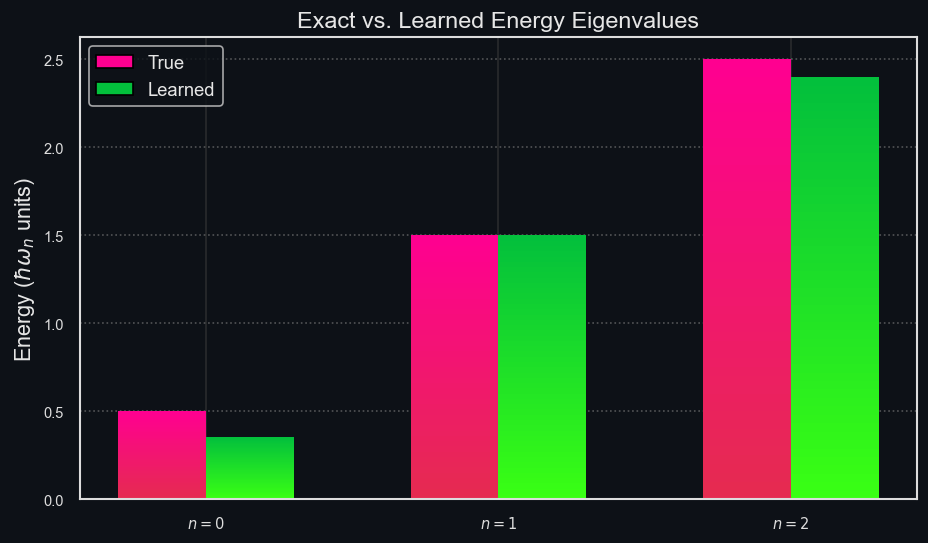

In [12]:
E_learned = model.E_theta().detach()    # shape (n_states,)

fig = plot_energy_spectrum(
    E_true=E_true,          # whatever tensor you already have
    E_learned=E_learned,
    out_path=pathlib.Path("../artifacts/demo_visuals/learned_energies.png"),
)

## 5️⃣ Figure 5: Probability densities $|\hat{\psi}_n^\theta(x)|^2$ vs. observations
- Plot
    -  $|\hat{\psi}_n^\theta(x)|^2$
    - Observed $\rho_n^\text{obs}(x)$
- Message
    - Data anchoring
    - Indirect supervision
    - Why phase remains unconstrained

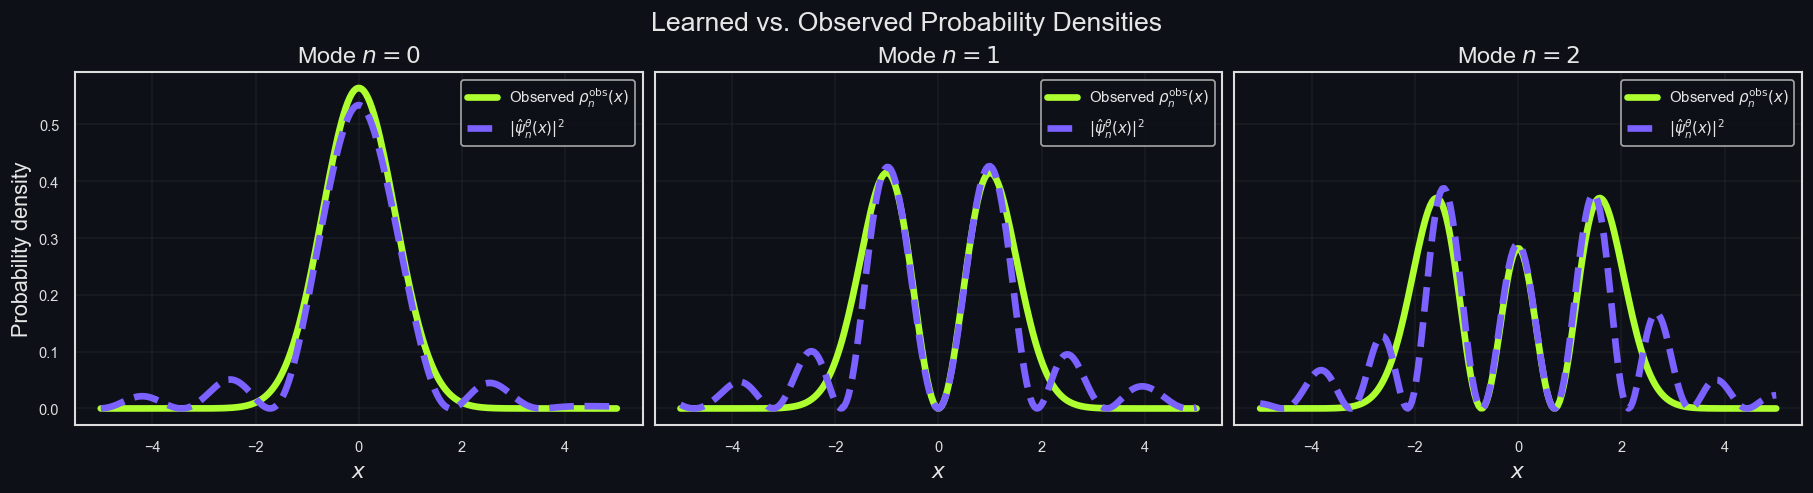

In [13]:
# --------------------------------------------------------------
# Create fake observed data for `rho_obs` (ideal case)
# --------------------------------------------------------------
rho_obs = [torch.abs(pt.squeeze())**2 for pt in psi_true]    # ideal case

fig = plot_density_vs_observed(
    x=x,
    psi_learned=psi_pred,
    rho_obs=rho_obs,
    lambdas=None,
    out_path=pathlib.Path("../artifacts/demo_visuals/density.png"),
)

## 7️⃣ Figure 6a: POD singular values
- Plot
    - Singular values $\sigma_k$ vs. $k$ (log scale)
- Message
    - Effective dimensionality
    - Redundant modes
    - Capacity vs. constraint
- Failure mode
    - One dominant singular value -> collapse (❓

## 7️⃣ Figure 6b: First three POD spatial modes vs. learned wavefunctions vs. ground-truth wavefunctions
- Plot
    - Compare POD spatial modes to $\hat{\psi}_n^\theta(x)$
- Message
    - Learned basis is not equivalent to ground truth physical eigenbasis
    - Still explains data

In [14]:
from pod import physical_pod_decomposition

# Stack the learned wavefunctions column-wise to feed POD
psi_matrix = torch.stack(psi_learned_detached, dim=1).squeeze(-1)

pod_modes_physical, S, Vh, U = physical_pod_decomposition(
    psi_matrix,
    dx,
    reference_modes=psi_matrix,
    align_signs=True,
)

print("psi_matrix shape :", psi_matrix.shape)                 # expect (N, n_modes)
print("U shape          :", U.shape)           # expect (N, n_modes)
print('U_phys shape     :', pod_modes_physical.shape)
print("S shape          :", S.shape)

psi_matrix shape : torch.Size([256, 3])
U shape          : torch.Size([256, 3])
U_phys shape     : torch.Size([256, 3])
S shape          : torch.Size([3])



Singular Values:
------------------------------
  Mode (k) |         Sigma_k
------------------------------
         1 |    1.000000e+00
         2 |    1.000000e+00
         3 |    1.000000e+00
------------------------------


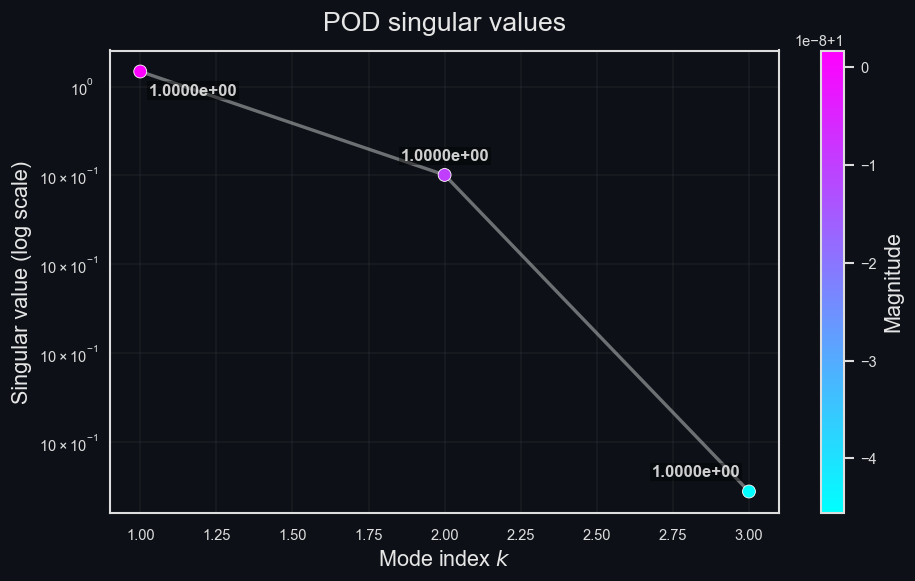

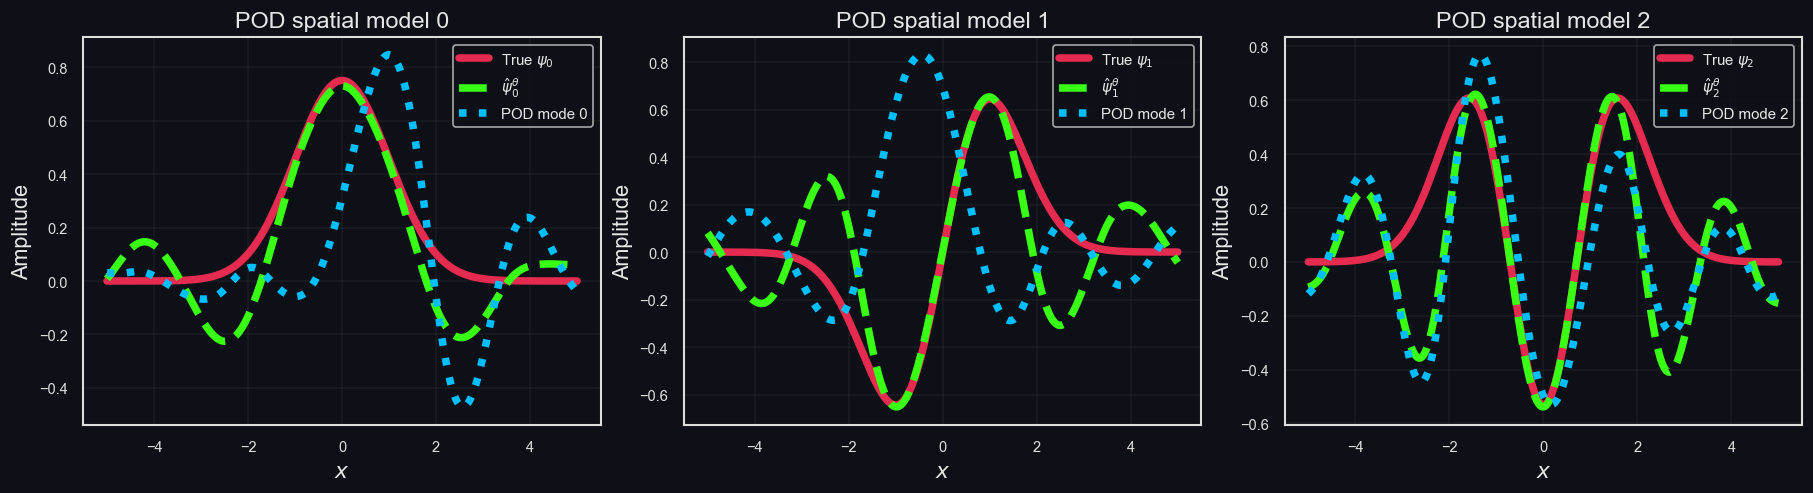

In [15]:
fig = plot_pod_singular_values(
    singular_values=S,
    out_path=pathlib.Path("../artifacts/demo_visuals/pod_singular_values.png"),
)

fig = plot_pod_first_three_spatial_modes(
    x=x,
    spatial_modes=pod_modes_physical.unsqueeze(-1),
    ground_truth=psi_true_detached,
    psi_learned=psi_learned_detached,
    lambdas=None,
    out_path=pathlib.Path("../artifacts/demo_visuals/pod_modes.png"),
)

In [16]:
#cross_overlap = cross_overlap_matrix(
#    pod_modes_physical,
#    psi_matrix,
#    dx = dx
#)

## 7️⃣ Figure 7a: Overlap matrix heatmap (POD diagnostic)
- Plot
    - Heatmap of $\langle \hat{\psi}_m^\theta | \hat{\psi}_n^\theta \rangle$
- Message
    - Near-orthogonality emerges (or not)
    - Coupling through shared $V(x)$
- ✨ This is very important for interpretability.

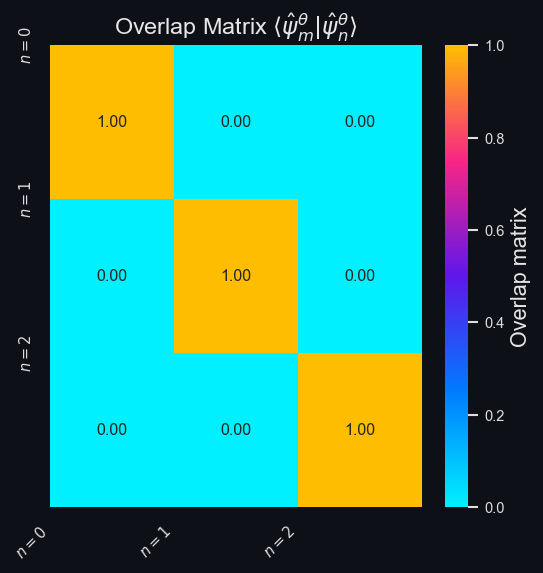

In [17]:
fig = plot_overlap_heatmap(
    psi_theta=psi_learned_detached,
    dx=dx,
    lambdas=None,
    out_path=pathlib.Path("../artifacts/demo_visuals/overlap_heatmap.png"),
)

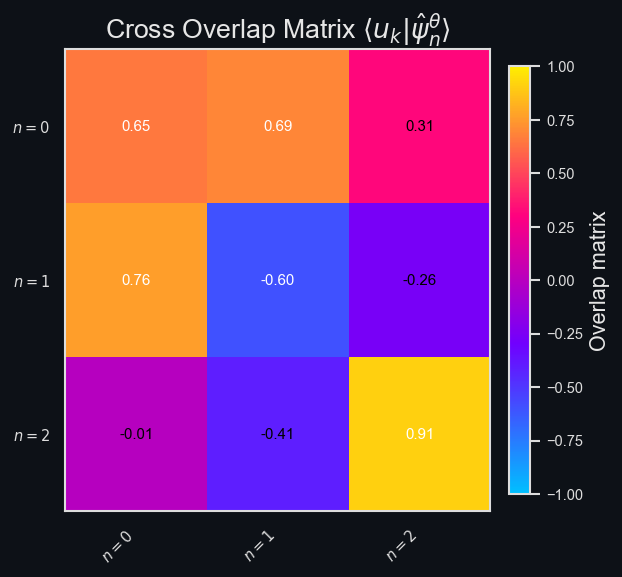

In [18]:
fig = plot_cross_overlap_heatmap(
    pod_modes_physical,
    psi_matrix,
    dx=dx,
    out_path=pathlib.Path("../artifacts/demo_visuals/cross_overlap_heatmap.png"),
)

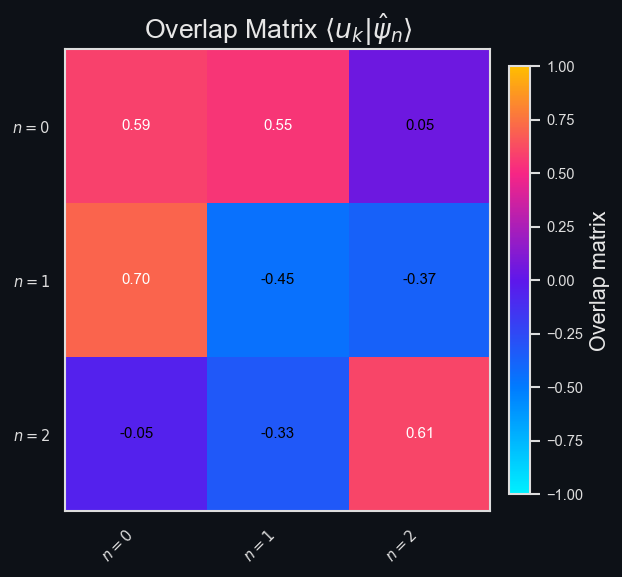

In [19]:
fig = plot_pod_eigen_alignment(
    pod_modes_physical,
    torch.stack(psi_true, dim=0).T,
    dx=dx,
    out_path=pathlib.Path("../artifacts/demo_visuals/pod_eigen_alignment.png"),
)

## 7️⃣ Figure 7b: Temporal modes heatmap (Composition Matrix V)
- Plot
    - Heatmap of $V_{nk}$ (columns of $V$)
- Message
    - Shows how each POD mode contributes to each learned state.
    - Ideally diagonal (one POD mode = one learned state).

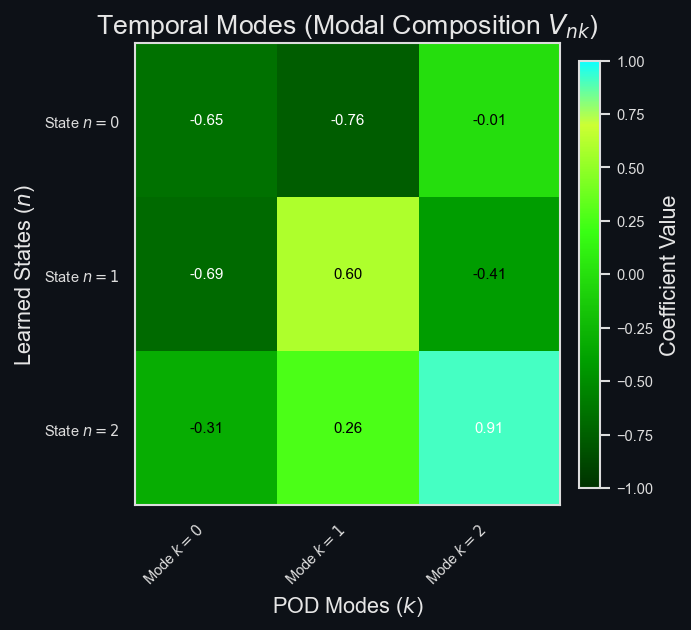

In [20]:
fig = plot_pod_temporal_modes(
    Vh=Vh,
    out_path=pathlib.Path("../artifacts/demo_visuals/pod_temporal_modes.png"),
)

## 7️⃣ Figure 7c: Temporal mode overlap and cross-overlap
- Plot
    - Heatmap of $\langle v_m | v_n \rangle$ (should be Identity)
    - Heatmap of $|\langle \mathbf{e}_n | v_k \rangle|$

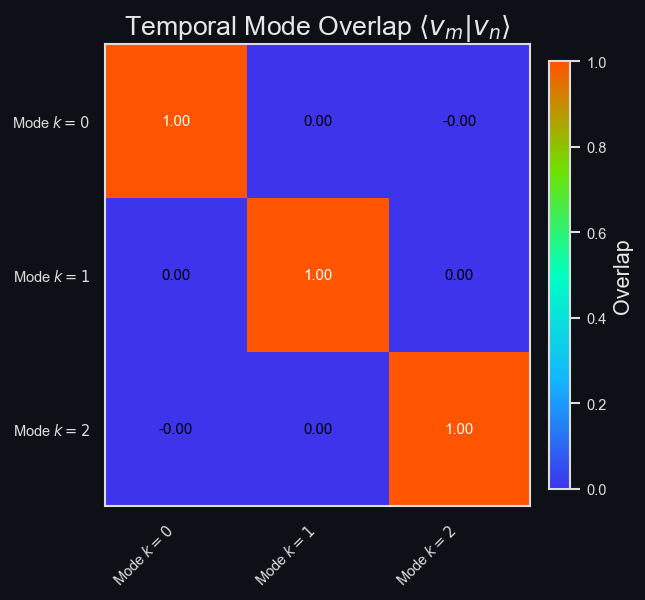

In [21]:
fig = plot_pod_temporal_overlap_heatmap(
    Vh=Vh,
    out_path=pathlib.Path("../artifacts/demo_visuals/pod_temporal_overlap.png"),
)

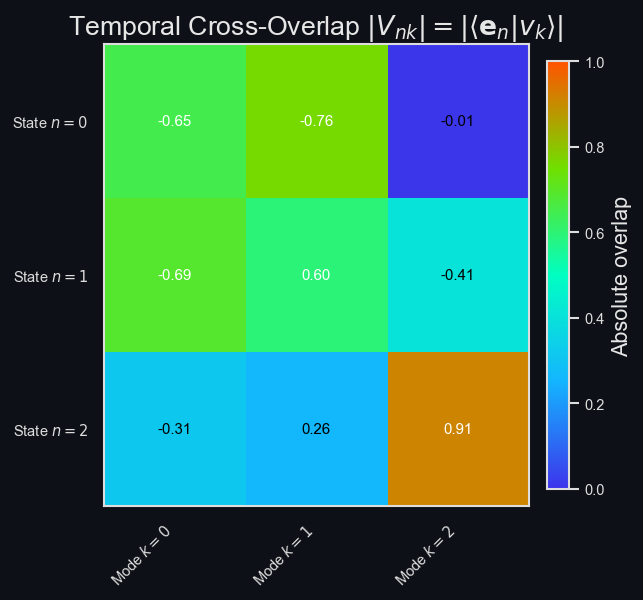

In [22]:
fig = plot_pod_temporal_cross_overlap_heatmap(
    Vh=Vh,
    out_path=pathlib.Path("../artifacts/demo_visuals/pod_temporal_cross_overlap.png"),
)

# Figure 8: Hilbert Phase Portrait

In [23]:
print(f"x shape: {x.shape}")
print(f"psi_pred[0] shape: {psi_pred[0].shape}")
print(f"psi_true[0] shape: {psi_true[0].shape}")

x shape: torch.Size([256, 1])
psi_pred[0] shape: torch.Size([256])
psi_true[0] shape: torch.Size([256])


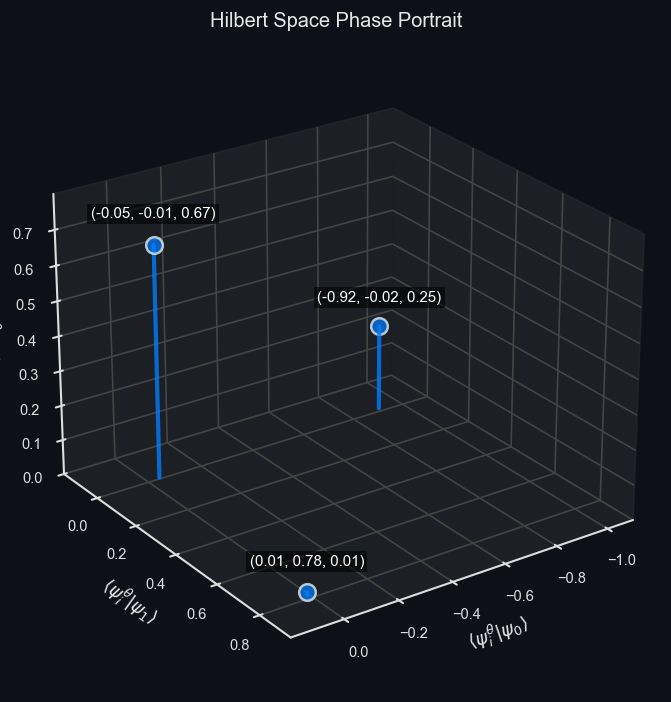

In [24]:
# Stack the list of wavefunctions into a 2D tensor (n_modes, n_grid)
psi_learned_stacked = torch.stack(psi_pred, dim=1)      # Shape: (N, n_modes)
psi_true_stacked = torch.stack(psi_true, dim=1)         # Shape: (N, n_eigenmodes)

fig = plot_hilbert_phase_portrait(
    learned_wavefunctions=psi_learned_stacked,
    true_wavefunctions=psi_true_stacked,
    x=x,
    out_path=pathlib.Path("../artifacts/demo_visuals/hilbert_portrait.png"),
)

In [25]:
def plot_spectral_energy_cascade(
    learned_wavefunctions: np.ndarray,
    energies: np.ndarray,
    out_path: Path,
):
    """
    Compare POD singular values with Hamiltonian energy spectrum.
    """

    spatial_modes, singular_values, _ = pod_decomposition(learned_wavefunctions)

    n = min(len(singular_values), len(energies))

    fig, ax1 = plt.subplots(figsize=(7, 5))

    # POD spectrum
    sns.lineplot(
        x=np.arange(1, n + 1),
        y=singular_values[:n],
        marker="o",
        ax=ax1,
        label="POD singular values",
    )

    ax1.set_yscale("log")
    ax1.set_xlabel("Mode index")
    ax1.set_ylabel("Singular value")

    # second axis for energies
    ax2 = ax1.twinx()

    sns.lineplot(
        x=np.arange(1, n + 1),
        y=energies[:n],
        marker="s",
        ax=ax2,
        linestyle="--",
        label="Energy eigenvalues",
    )

    ax2.set_ylabel("Energy")

    ax1.set_title("Spectral Energy Cascade")

    fig.savefig(
        out_path,
        dpi=200,
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
    )

    plt.close(fig)

In [26]:
def plot_partition_function_spectrum(
    learned_wavefunctions: np.ndarray,
    out_path: Path,
):
    """
    Interpret POD spectrum as a thermodynamic ensemble.
    """

    _, singular_values, _ = pod_decomposition(learned_wavefunctions)

    # probability weights
    p = singular_values**2
    p = p / np.sum(p)

    # effective energies
    E_eff = -np.log(p + 1e-12)

    # entropy
    entropy = -np.sum(p * np.log(p + 1e-12))

    modes = np.arange(1, len(p) + 1)

    fig, ax1 = plt.subplots(figsize=(7,5))

    sns.lineplot(
        x=modes,
        y=p,
        marker="o",
        ax=ax1,
        label="Boltzmann weights",
    )

    ax1.set_ylabel("Mode probability")
    ax1.set_xlabel("Mode index")

    ax2 = ax1.twinx()

    sns.lineplot(
        x=modes,
        y=E_eff,
        marker="s",
        linestyle="--",
        ax=ax2,
        label="Effective energy",
    )

    ax2.set_ylabel("Effective energy")

    ax1.set_title(f"POD Partition Function Spectrum (Entropy={entropy:.3f})")

    fig.savefig(
        out_path,
        dpi=200,
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
    )

    plt.close(fig)

## 8️⃣ Figure 8: Loss-weight bifurcation diagram
🥅 Generate a bifurcation diagram that gives us identifiability information.

### 📈 Plot
- $x$-axis: $\frac{\lambda_\text{phys}}{\lambda_\text{data}}$ (log scale)
- $y$-axis (multiple panels):
    - $|| V - V_\text{ref} ||_2$
    - smallest POD singular value
    - max off-diagonal overlap

### 🗝️ Key takeaway
> As physics dominace increases, identifiability goes through sharp transitions. Note that beyond a critical regime (❓ What is this?), the ${\psi_n}_\theta$ collapse into a low-dimensional subspace regardless of whether they satisfy the PDE.

- Makes interpretability axes concrete
- Shows where physics stops helping
- Distinguishes "stable but meaningless" from "informative"

### ✖️ Failure modes
- Flat $V(x)$ and low loss
- POD rank collapse
- Artificial orthogonality

In [27]:
# figure 8 code